# 09 · Validation: how far can the model be trusted?

A single AUROC does not validate a model. This notebook asks the questions an examiner, or a clinician, would ask next:

1. **Does it work equally well for different kinds of people?** (subgroups and fairness)
2. **If we act on a risk cut-off, how many people are flagged, and how often is the flag right?** (thresholds)
3. **Are the predicted risks the right size at centres the model never saw?** (calibration)
4. **Is using the model better than simple policies such as "follow up everyone"?** (decision curve)
5. **Did leaving out people with unknown 3-year status distort the conclusions?** (survival analysis on everyone)

Model: XGBoost, first-visit features, dementia within 3 years. All numbers are on the **internal test set** (held-out participants) and the **external set** (9 held-out centres). Produced by `scripts/validate.py`.

**What kind of validation this is.** Retrospective, on research volunteers, with internal and external-style test sets. It is not prospective and not clinical validation: nobody used the model to make a decision about a patient.

In [1]:
import sys, json
sys.path.insert(0, "../scripts")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import nacc_utils as nu

nu.set_style()
r = json.loads((nu.REPORTS / "phase8_validation_results.json").read_text())
print({s: (r[s]["n"], r[s]["events"]) for s in ["test", "external"]})

{'test': (2286, 332), 'external': (4064, 545)}


## 1. Subgroups

For each subgroup: how well the model ranks people (AUROC) and whether the average predicted risk matches the observed rate. Subgroups with fewer than 15 events are listed without an AUROC, because the estimate would be meaningless.

In [2]:
def sub_table(s):
    rows = {}
    for k, v in r[s]["subgroups"].items():
        rows[k] = {"n": v["n"], "Events": v["events"], "Observed %": round(v["observed_rate"] * 100, 1), "Predicted %": round(v["mean_predicted"] * 100, 1),
                   "AUROC (95% interval)": f"{v['auroc']:.3f} ({v['auroc_ci'][0]:.3f}-{v['auroc_ci'][1]:.3f})" if "auroc" in v else "too few events"}
    return pd.DataFrame(rows).T
sub_table("test")

,n,Events,Observed %,Predicted %,AUROC (95% interval)
Sex: Female,1338,162,12.1,11.9,0.950 (0.936-0.963)
Sex: Male,948,170,17.9,18.2,0.919 (0.897-0.940)
Age: 65-74,963,99,10.3,11.7,0.952 (0.932-0.967)
Age: 75-84,732,157,21.4,19.1,0.904 (0.877-0.928)
Age: 85+,124,30,24.2,23.0,0.852 (0.776-0.924)
Age: Under 65,467,46,9.9,11.0,0.976 (0.960-0.989)
Race: Black,304,31,10.2,10.0,0.948 (0.913-0.977)
Race: Other / unknown,169,28,16.6,13.9,0.963 (0.934-0.987)
Race: White,1813,273,15.1,15.3,0.933 (0.918-0.945)
Education: 12 years or less,400,92,23.0,19.0,0.926 (0.899-0.952)


In [3]:
sub_table("external")

,n,Events,Observed %,Predicted %,AUROC (95% interval)
Sex: Female,2507,272,10.8,12.0,0.947 (0.934-0.957)
Sex: Male,1557,273,17.5,19.8,0.941 (0.928-0.952)
Age: 65-74,1463,191,13.1,14.7,0.956 (0.944-0.967)
Age: 75-84,1044,191,18.3,19.9,0.937 (0.920-0.951)
Age: 85+,490,107,21.8,20.4,0.888 (0.845-0.926)
Age: Under 65,1067,56,5.2,8.0,0.958 (0.933-0.979)
Race: Black,471,26,5.5,7.8,0.951 (0.917-0.978)
Race: Other / unknown,246,20,8.1,9.8,0.955 (0.916-0.986)
Race: White,3347,499,14.9,16.4,0.943 (0.934-0.952)
Education: 12 years or less,744,137,18.4,20.1,0.920 (0.898-0.941)


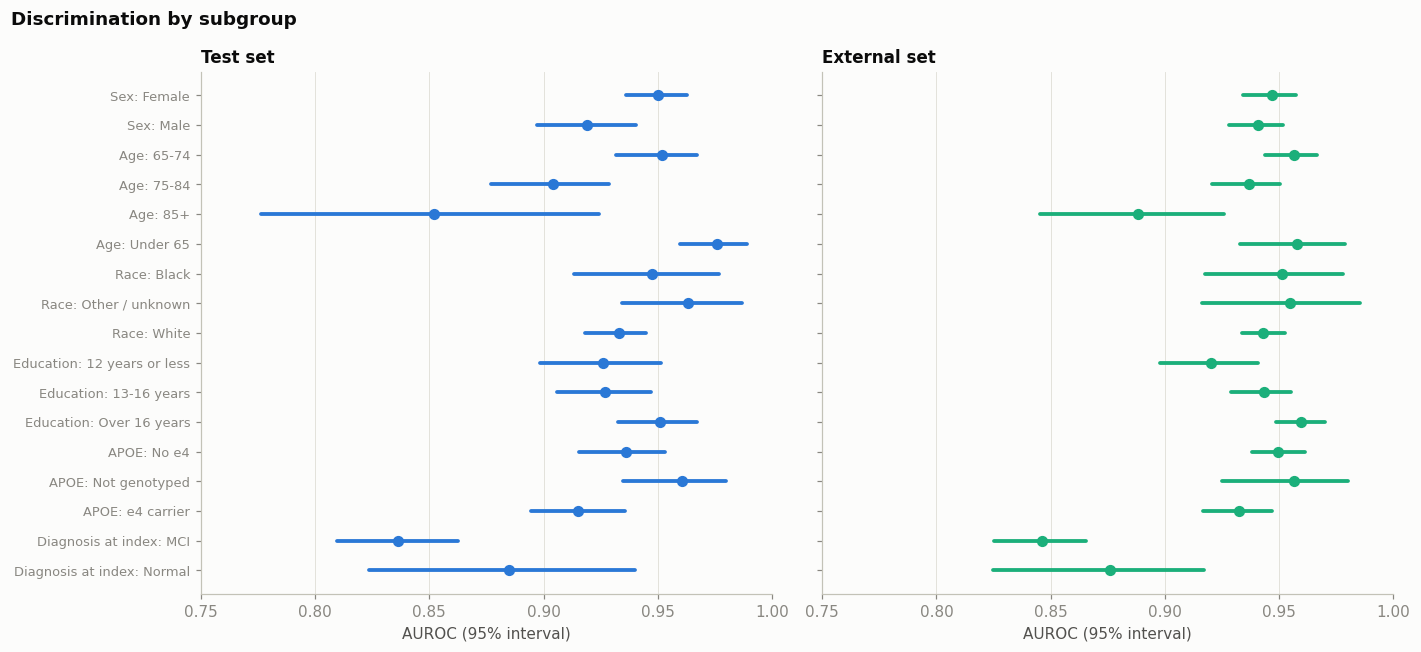

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
keys = [k for k in r["test"]["subgroups"] if "auroc" in r["test"]["subgroups"][k] and "auroc" in r["external"]["subgroups"].get(k, {})]
for ax, s, color in zip(axes, ["test", "external"], [nu.BLUE, nu.AQUA]):
    for i, k in enumerate(keys[::-1]):
        v = r[s]["subgroups"][k]
        ax.plot(v["auroc_ci"], [i, i], color=color, lw=2.5, solid_capstyle="round"); ax.scatter([v["auroc"]], [i], color=color, s=40, zorder=3)
    ax.set_yticks(range(len(keys)), keys[::-1], fontsize=8.5); ax.set_xlim(0.75, 1.0); ax.set_xlabel("AUROC (95% interval)")
    ax.set_title(f"{s.capitalize()} set"); ax.grid(axis="y", visible=False)
fig.suptitle("Discrimination by subgroup", x=0.01, ha="left", fontweight="bold"); fig.tight_layout(); nu.savefig(fig, "09_subgroups"); plt.show()

**Reading the subgroups.**

* **Sex, race and education:** discrimination is similar across groups (AUROC about 0.92 to 0.96), and intervals overlap. There is no sign that the model ranks Black participants worse than White participants. The Black and "other" groups are small (about 25 to 30 events each), so this is "no difference detected", not "proven equal".
* **Age:** performance falls with age, from about 0.96 under 65 to about 0.85 to 0.89 at 85 and over. In the oldest group conversion is common whatever the test scores, so people are harder to separate. This should be stated as a limitation for the oldest patients.
* **Diagnosis at index:** about 0.84 within MCI and about 0.88 within normal. These are the honest within-group figures already discussed in notebook 06.
* **Calibration by group:** predicted and observed rates are mostly within 2 percentage points. Two gaps stand out. On the test set the model under-predicts for people with 12 or fewer years of education (19% predicted, 23% observed) and for people not genotyped (24% against 28%). On the external centres it over-predicts for Black participants (7.8% against 5.5%). These are the groups to watch if the model were ever taken further.

## 2. Acting on a threshold

Thresholds were fixed in advance (5%, 10%, 20%, 30%, 50% predicted risk), not tuned on the test data.

* **Sensitivity:** of the people who did convert, what share was flagged?
* **Specificity:** of those who did not, what share was correctly left alone?
* **PPV:** of the people flagged, what share converted?
* **NPV:** of the people not flagged, what share did not convert?

In [5]:
def thr(s):
    t = pd.DataFrame(r[s]["thresholds"]).T
    t.index = [f"Risk ≥ {float(i)*100:.0f}%" for i in t.index]
    t["flagged_pct"] = t["flagged_pct"].round(1)
    for c in ["sensitivity", "specificity", "ppv", "npv"]: t[c] = (t[c] * 100).round(1)
    return t.rename(columns={"flagged_pct": "Flagged %", "sensitivity": "Sensitivity %", "specificity": "Specificity %", "ppv": "PPV %", "npv": "NPV %"})
pd.concat({"Test": thr("test"), "External": thr("external")}, axis=1)

Test                                          External  \
           Flagged % Sensitivity % Specificity % PPV % NPV % Flagged %   
Risk ≥ 5%       36.0          95.5          74.1  38.5  99.0      36.7   
Risk ≥ 10%      29.5          91.6          81.1  45.1  98.3      29.6   
Risk ≥ 20%      22.1          83.4          88.3  54.7  96.9      23.4   
Risk ≥ 30%      18.3          76.8          91.7  61.0  95.9      19.0   
Risk ≥ 50%      12.2          59.9          96.0  71.6  93.4      13.2   

                                                    
           Sensitivity % Specificity % PPV % NPV %  
Risk ≥ 5%           96.3          72.5  35.2  99.2  
Risk ≥ 10%          94.3          80.4  42.7  98.9  
Risk ≥ 20%          89.9          86.9  51.6  98.2  
Risk ≥ 30%          83.3          90.9  58.7  97.2  
Risk ≥ 50%          67.5          95.2  68.7  95.0

* At a 10% cut-off the model flags about 30% of people and catches 92 to 94% of those who convert; a negative result is right about 98 to 99% of the time. But fewer than half of the people flagged actually convert (PPV about 45%).
* At 50% the flags are right about 70% of the time, but 30 to 40% of converters are missed.

No threshold is "correct". The choice depends on what happens to a flagged person. If the consequence is a closer follow-up visit, a low threshold with many false alarms is acceptable. This is a decision for clinicians, and the interface should show the risk, not a yes/no verdict.

The high NPV partly reflects the cohort: most people who start cognitively normal do not convert within 3 years whatever the model says.

## 3. Calibration at unseen centres

A calibration **slope** of 1 and **intercept** of 0 mean the predicted risks are the right size. A slope below 1 means predictions are too extreme (over-confident); a negative intercept means risks are too high on average.

In [6]:
pd.DataFrame({s.capitalize(): {"Calibration slope": round(r[s]["calibration"]["slope"], 3), "Calibration intercept": round(r[s]["calibration"]["intercept"], 3),
                               "Mean predicted risk %": round(r[s]["calibration"]["mean_predicted"] * 100, 1), "Observed rate %": round(r[s]["calibration"]["observed_rate"] * 100, 1)}
              for s in ["test", "external"]})

,Test,External
Calibration slope,1.010,1.098
Calibration intercept,0.009,-0.194
Mean predicted risk %,14.500,15.000
Observed rate %,14.500,13.400


* **Internal test set:** slope 1.01, intercept 0.01, predicted 14.5% against observed 14.5%. Essentially perfect.
* **External centres:** slope 1.10, intercept -0.19, predicted 15.0% against observed 13.4%. The model **over-estimates risk slightly** at the new centres.

This is the usual pattern when a model moves to new sites: ranking transfers well, but the absolute level drifts because each centre recruits a slightly different mix of people. The practical lesson for deployment is that a model like this would need its risks re-checked, and probably recalibrated, on local data before the numbers shown to a clinician could be relied on.

## 4. Decision curve: is the model worth using?

**Net benefit** weighs true positives against false positives at a given threshold. The model is compared with two policies that need no model: "act on everyone" and "act on no one" (net benefit 0). If the model's curve is not above both, it adds nothing at that threshold.

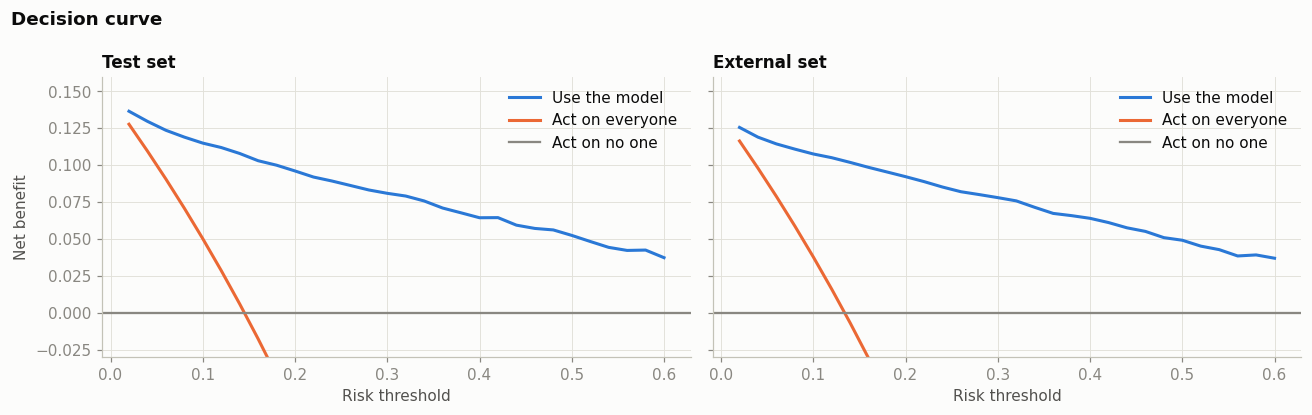

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, s in zip(axes, ["test", "external"]):
    d = r[s]["decision_curve"]
    ax.plot(d["threshold"], d["model"], color=nu.BLUE, label="Use the model")
    ax.plot(d["threshold"], d["treat_all"], color=nu.ORANGE, label="Act on everyone")
    ax.axhline(0, color=nu.MUTED, lw=1.5, label="Act on no one")
    ax.set_ylim(-0.03, 0.16); ax.set_xlabel("Risk threshold"); ax.set_title(f"{s.capitalize()} set"); ax.legend(loc="upper right")
axes[0].set_ylabel("Net benefit"); fig.suptitle("Decision curve", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); nu.savefig(fig, "09_decision_curve"); plt.show()

The model's curve is above both simple policies at every threshold examined (2% to 60%), on both sets. At very low thresholds the advantage over "act on everyone" is small, because nearly everybody is flagged anyway.

This says the model would be *useful for prioritising* in a population like NACC. It does not say that acting on it improves patient outcomes; only a prospective study could show that.

## 5. Did excluding people with unknown status matter?

The classifier was trained and tested only on people whose 3-year status is known, about half of those eligible. A **Cox proportional hazards model** uses time to dementia and keeps everyone: a person followed for one year contributes that one year of "did not convert". If the conclusions were an artefact of the exclusion, they should change here.

The **C-index** is the survival-analysis counterpart of AUROC.

In [8]:
sv = r["survival"]
print("Participants (dementia events), including those with unknown 3-year status:", {s: (v["n"], v["events"]) for s, v in sv["cohort"].items()})
pd.DataFrame({s.capitalize(): {"C-index, all feature groups": round(sv[s]["c_index"]["All feature groups"], 3),
                               "C-index, without cardiovascular group": round(sv[s]["c_index"]["Without cardiovascular group"], 3),
                               "Gain from cardiovascular group": f"{sv[s]['gain_from_cardiovascular']:+.4f} ({sv[s]['gain_ci'][0]:+.4f} to {sv[s]['gain_ci'][1]:+.4f})"}
              for s in ["test", "external"]})

Participants (dementia events), including those with unknown 3-year status: {'train': (16054, 3142), 'val': (3355, 634), 'test': (3462, 649), 'external': (5837, 1078)}


,Test,External
"C-index, all feature groups",0.891,0.903
"C-index, without cardiovascular group",0.89,0.903
Gain from cardiovascular group,+0.0011 (-0.0009 to +0.0030),+0.0004 (-0.0008 to +0.0016)


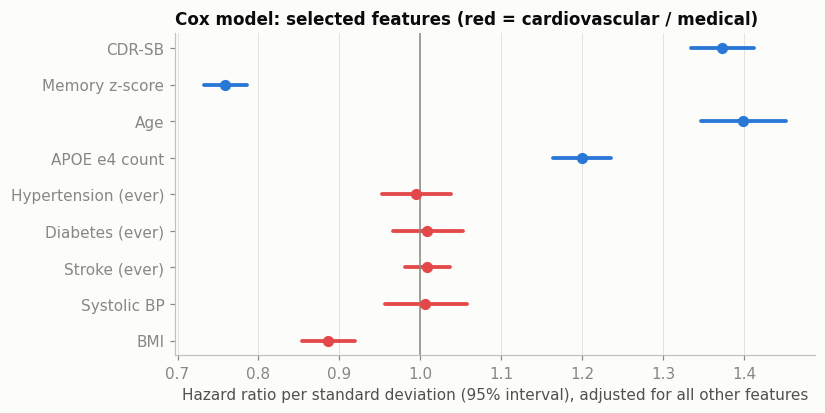

,exp(coef),exp(coef) lower 95%,exp(coef) upper 95%
CDR-SB,1.37,1.33,1.41
Memory z-score,0.76,0.73,0.79
Age,1.40,1.35,1.45
APOE e4 count,1.20,1.16,1.24
Hypertension (ever),1.00,0.95,1.04
Diabetes (ever),1.01,0.97,1.05
Stroke (ever),1.01,0.98,1.04
Systolic BP,1.01,0.96,1.06
BMI,0.89,0.85,0.92


In [9]:
hr = pd.DataFrame(sv["hazard_ratio_per_sd"]).T
names = {"CDRSUM": "CDR-SB", "z_memory": "Memory z-score", "age": "Age", "apoe_e4_count": "APOE e4 count", "htn_ever": "Hypertension (ever)",
         "diabetes_ever": "Diabetes (ever)", "stroke_ever": "Stroke (ever)", "bp_sys": "Systolic BP", "bmi": "BMI"}
fig, ax = plt.subplots(figsize=(7.5, 3.8))
for i, k in enumerate(list(names)[::-1]):
    cardio = k in ("htn_ever", "diabetes_ever", "stroke_ever", "bp_sys", "bmi")
    c = nu.RED if cardio else nu.BLUE
    ax.plot([hr.loc[k, "exp(coef) lower 95%"], hr.loc[k, "exp(coef) upper 95%"]], [i, i], color=c, lw=2.5, solid_capstyle="round")
    ax.scatter([hr.loc[k, "exp(coef)"]], [i], color=c, s=40, zorder=3)
ax.axvline(1, color=nu.MUTED, lw=1); ax.set_yticks(range(len(names)), list(names.values())[::-1]); ax.grid(axis="y", visible=False)
ax.set_xlabel("Hazard ratio per standard deviation (95% interval), adjusted for all other features")
ax.set_title("Cox model: selected features (red = cardiovascular / medical)"); nu.savefig(fig, "09_hazard_ratios"); plt.show()
hr.rename(index=names).round(2)

**The conclusions hold when everyone is included.**

* The cohort is about half as large again (3,462 test participants instead of 2,286), and discrimination is still high (C-index about 0.89 to 0.90).
* The cardiovascular group again adds essentially nothing: +0.001 on the test set and +0.0004 on the external centres, both intervals including zero. This is the same answer the classifier gave, from a different method on a larger group.
* Adjusted hazard ratios tell the same story from another angle. CDR-SB, memory, age and APOE e4 have clear effects. Hypertension, diabetes, stroke history and systolic pressure have hazard ratios of 0.99 to 1.01 with intervals that include 1.
* **BMI** is the exception: higher BMI goes with *lower* hazard (about 0.89 per standard deviation). As noted in notebook 03, weight loss tends to precede a dementia diagnosis, so this is most plausibly the disease affecting weight, not weight protecting against the disease. It is a good example of why none of these associations can be read as causes.

The hazard ratios come from a penalised model with many correlated features, so they are shrunk towards 1 and are for comparison between features, not for quoting as clinical effect sizes.

## 6. Validation summary

| Check | Result |
|---|---|
| Discrimination, internal test | AUROC 0.938 (0.926-0.948) |
| Discrimination, 9 held-out centres | AUROC 0.946 (0.938-0.954) |
| Within MCI / within normal | About 0.84 / about 0.88 |
| Subgroups | Similar by sex, race, education; lower at 85 and over |
| Calibration | Excellent internally; slight over-estimate at external centres (15.0% predicted, 13.4% observed) |
| Decision curve | Better than "act on everyone" and "act on no one" at every threshold from 2% to 60% |
| Survival analysis including censored participants | Same conclusions; cardiovascular gain +0.001 |

**Still missing, and to be stated as limitations**

* A truly external cohort (for example ADNI). The held-out centres are still NACC centres using the same forms.
* Prospective use. Nothing here shows the model changes care or outcomes.
* Confirmed conversions. A single visit with a dementia diagnosis counts as an event; some people later revert.
* Small numbers in several subgroups, and very few converters among cognitively normal participants.